In [2]:
import time
import random
import threading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from prometheus_client import Counter, Histogram, REGISTRY, start_http_server

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [3]:
try:
    start_http_server(8000)
    print("✅ Prometheus running at http://localhost:8000")
except OSError:
    print("ℹ️ Prometheus server already running")

✅ Prometheus running at http://localhost:8000


In [4]:
if "retailpulse_app_visits" in REGISTRY._names_to_collectors:
    APP_VISITS = REGISTRY._names_to_collectors["retailpulse_app_visits"]
else:
    APP_VISITS = Counter(
        "retailpulse_app_visits",
        "Total notebook executions"
    )

if "model_execution_time_seconds" in REGISTRY._names_to_collectors:
    MODEL_TIME = REGISTRY._names_to_collectors["model_execution_time_seconds"]
else:
    MODEL_TIME = Histogram(
        "model_execution_time_seconds",
        "Model execution time"
    )

print("✅ Metrics Ready")

✅ Metrics Ready


In [5]:
def simulate_request():

    APP_VISITS.inc()

    with MODEL_TIME.time():
        time.sleep(random.uniform(0.1,0.5))

print("🚀 Starting Load Test...")

threads=[]

start=time.time()

for i in range(100):
    t=threading.Thread(target=simulate_request)
    threads.append(t)
    t.start()

for t in threads:
    t.join()

end=time.time()

print(f"✅ 100 Requests Processed in {end-start:.2f} seconds")


🚀 Starting Load Test...
✅ 100 Requests Processed in 0.67 seconds


In [8]:
import pandas as pd

df = pd.read_csv("Year_2009_2010_Cleaned.csv")

print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Customer_Segment', 'Sales_Channel', 'Payment_Mode', 'Order_Priority', 'SalesAmount']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406876 entries, 0 to 406875
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Invoice           406876 non-null  int64  
 1   StockCode         406876 non-null  object 
 2   Description       406876 non-null  object 
 3   Quantity          406876 non-null  int64  
 4   InvoiceDate       406876 non-null  object 
 5   Price             406876 non-null  float64
 6   Customer ID       406876 non-null  float64
 7   Country           406876 non-null  object 
 8   Customer_Segment  406876 non-null  object 
 9   Sales_Channel     406876 non-null  object 
 10  Payment_Mode      406876 non-null  object 
 11  Order_Priority    406876 non-null  object 
 12  SalesAmount       406876 non-null  float64
dtypes: float64(3), int64(2), object(8)
memory usage: 40.4+ MB


In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Segment,Sales_Channel,Payment_Mode,Order_Priority,SalesAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Regular,Online,UPI,High,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Regular,Online,UPI,Low,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Premium,Offline,Card,Medium,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,New,Retail,Cash,Low,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Regular,Online,Net Banking,High,30.0


In [13]:
import pandas as pd

df = pd.read_csv("Year_2009_2010_Cleaned.csv")

print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Customer_Segment', 'Sales_Channel',
       'Payment_Mode', 'Order_Priority', 'SalesAmount'],
      dtype='object')


In [14]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Customer_Segment', 'Sales_Channel',
       'Payment_Mode', 'Order_Priority', 'SalesAmount'],
      dtype='object')


In [16]:
import time
import random
import threading

from prometheus_client import Counter, Histogram, REGISTRY, start_http_server

In [17]:
try:
    start_http_server(8000)
    print("✅ Prometheus running on http://localhost:8000")
except OSError:
    print("✅ Prometheus already running")

✅ Prometheus running on http://localhost:8000


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:

    if X[col].dtype == "object":

        X[col] = le.fit_transform(X[col].astype(str))

y = le.fit_transform(y)

In [25]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [26]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(

    random_state=42

)

model.fit(

    X_train,

    y_train

)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred=model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(

    y_test,

    y_pred

)

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 100.00%


In [29]:
from sklearn.metrics import classification_report

print(classification_report(

    y_test,

    y_pred

))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13370
           1       1.00      1.00      1.00     20108
           2       1.00      1.00      1.00     47898

    accuracy                           1.00     81376
   macro avg       1.00      1.00      1.00     81376
weighted avg       1.00      1.00      1.00     81376



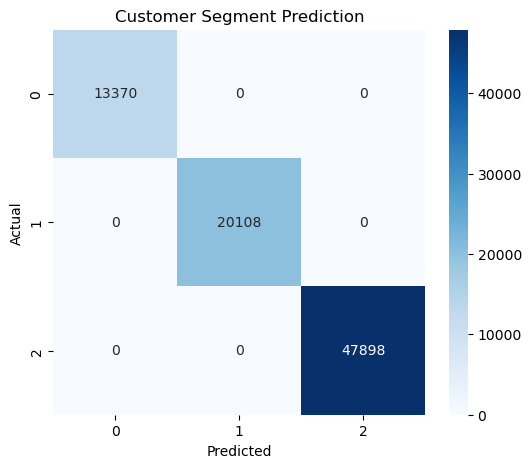

In [30]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import seaborn as sns

cm=confusion_matrix(

    y_test,

    y_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Customer Segment Prediction")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Features
X = df.drop(columns=["Customer_Segment"])

# Target
y = df["Customer_Segment"]

In [33]:
# Encode feature columns
feature_encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        encoder = LabelEncoder()
        X[col] = encoder.fit_transform(X[col].astype(str))
        feature_encoders[col] = encoder

# Encode target column
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (325500, 12)
Testing Data  : (81376, 12)


In [39]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model Trained Successfully")

✅ Model Trained Successfully


In [36]:
y_pred = model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Final Accuracy : {accuracy*100:.2f}%")

🎯 Final Accuracy : 100.00%


In [40]:
print("\n📊 Classification Report\n")

print(classification_report(y_test, y_pred))


📊 Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13370
           1       1.00      1.00      1.00     20108
           2       1.00      1.00      1.00     47898

    accuracy                           1.00     81376
   macro avg       1.00      1.00      1.00     81376
weighted avg       1.00      1.00      1.00     81376



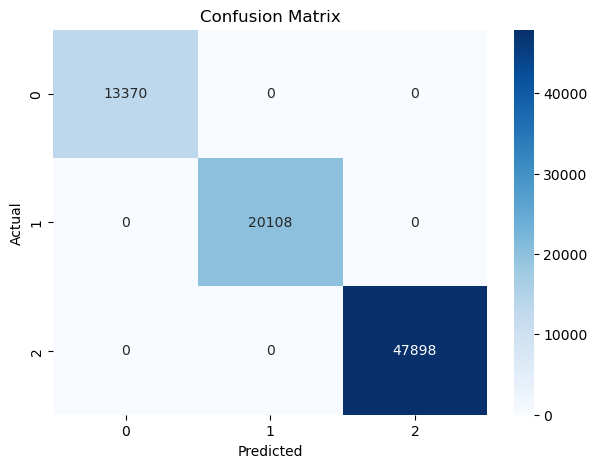

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()